In [8]:
from IPython.utils import io

with io.capture_output():
    %run ../01_eda_exploratory_data_analysis/01_data_overview.ipynb
    %run ../01_eda_exploratory_data_analysis/02_statistical_analysis.ipynb
    %run ../01_eda_exploratory_data_analysis/03_correlation_analysis.ipynb
    %run ../02_data_visualization/01_price_patterns.ipynb


print("✅ Connected to notebooks")

NameError: name 'DateFormatter' is not defined

NameError: name 'DateFormatter' is not defined

### Basic Volume Overview

In [6]:
# ====================================================================
# 📊 BASIC VOLUME OVERVIEW
# ====================================================================

print("=" * 60)
print("📊 BASIC VOLUME OVERVIEW")
print("=" * 60)

if 'volume' not in df.columns:
    print("❌ Volume column not found!")
else:
    print(f"\n📊 Volume Statistics:")
    print(f"  Total Volume: {df['volume'].sum():,.0f}")
    print(f"  Average Daily Volume: {df['volume'].mean():,.0f}")
    print(f"  Median Daily Volume: {df['volume'].median():,.0f}")
    print(f"  Max Daily Volume: {df['volume'].max():,.0f}")
    print(f"  Min Daily Volume: {df['volume'].min():,.0f}")
    print(f"  Volume Std Dev: {df['volume'].std():,.0f}")
    
    # Volume by quarter
    df['quarter'] = df.index.to_period('Q')
    quarterly_volume = df.groupby('quarter')['volume'].sum()
    print(f"\n📊 Quarterly Volume:")
    for quarter, vol in quarterly_volume.items():
        print(f"  {quarter}: {vol:,.0f}")

📊 BASIC VOLUME OVERVIEW

📊 Volume Statistics:
  Total Volume: 159,842,641
  Average Daily Volume: 404,665
  Median Daily Volume: 364,535
  Max Daily Volume: 2,102,312
  Min Daily Volume: 11,771
  Volume Std Dev: 286,388

📊 Quarterly Volume:
  2025Q3: 34,319,707
  2025Q4: 46,809,303
  2026Q1: 43,313,911
  2026Q2: 27,609,052
  2026Q3: 7,790,667


### Price vs Volume Relationship

📊 PRICE VS VOLUME RELATIONSHIP


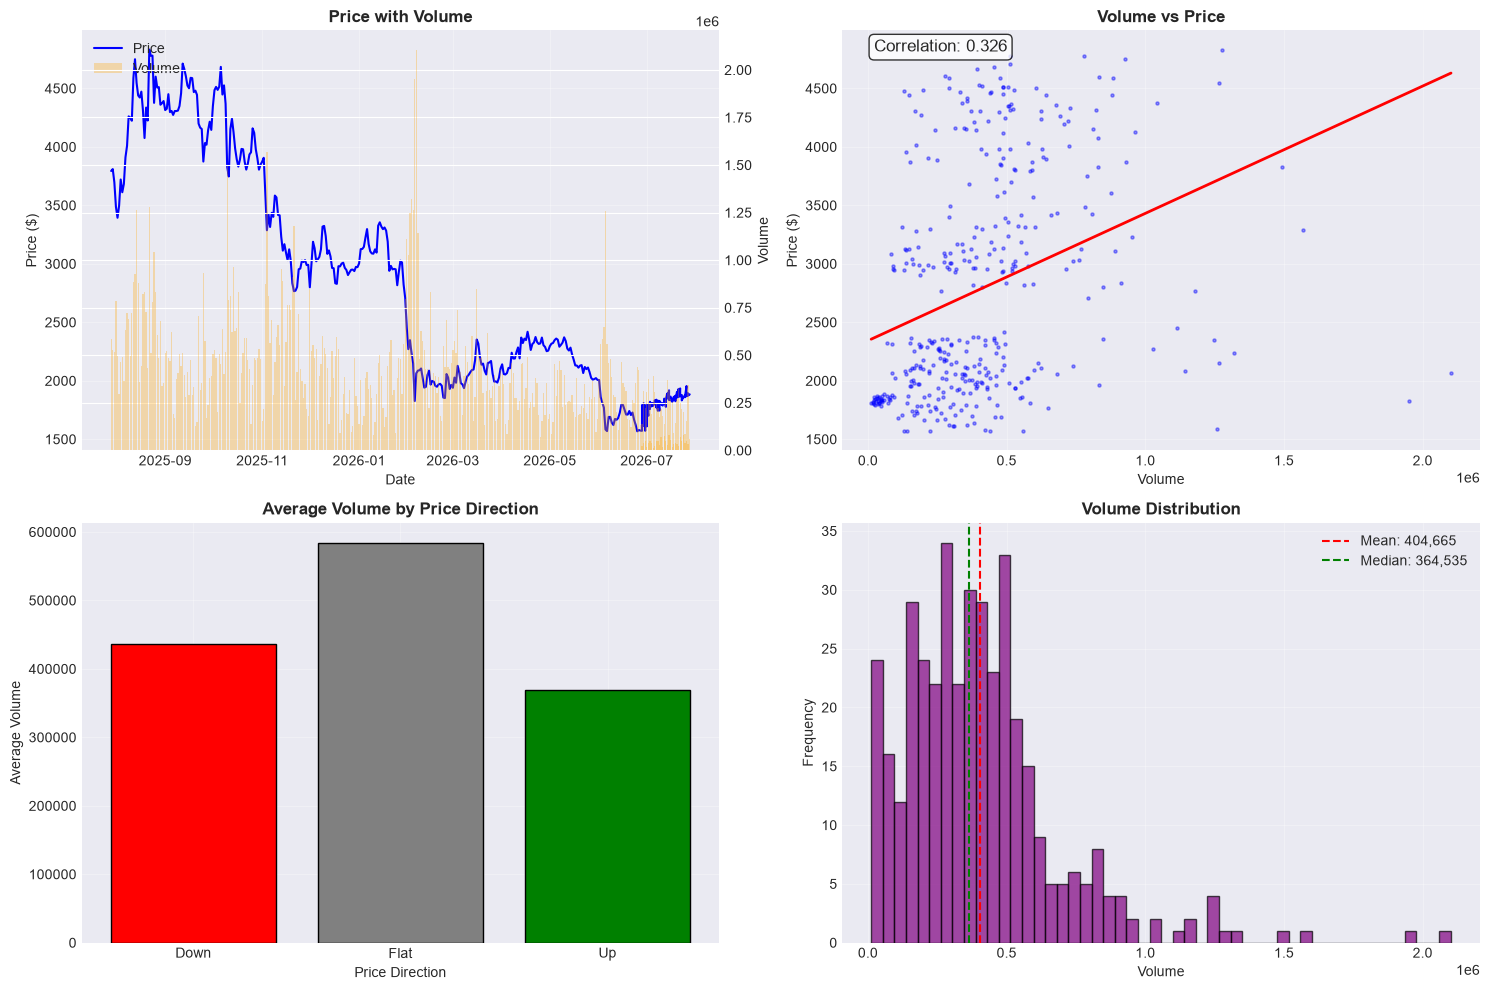

In [7]:
# ====================================================================
# 📊 PRICE VS VOLUME RELATIONSHIP
# ====================================================================

print("=" * 60)
print("📊 PRICE VS VOLUME RELATIONSHIP")
print("=" * 60)

if 'volume' in df.columns and price_col:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Price with Volume Bars
    axes[0, 0].plot(df.index, df[price_col], linewidth=1.5, color='blue', label='Price')
    ax2 = axes[0, 0].twinx()
    ax2.bar(df.index, df['volume'], alpha=0.3, color='orange', label='Volume')
    axes[0, 0].set_title('Price with Volume', fontweight='bold')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Price ($)')
    ax2.set_ylabel('Volume')
    lines1, labels1 = axes[0, 0].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[0, 0].legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Volume vs Price Scatter
    axes[0, 1].scatter(df['volume'], df[price_col], alpha=0.4, s=5, color='blue')
    
    # Add trend line
    from scipy import stats
    z = np.polyfit(df['volume'].dropna(), df[price_col].dropna(), 1)
    p = np.poly1d(z)
    x_sorted = np.sort(df['volume'].dropna())
    axes[0, 1].plot(x_sorted, p(x_sorted), color='red', linewidth=2)
    
    # Calculate correlation
    corr = df[['volume', price_col]].corr().iloc[0, 1]
    axes[0, 1].text(0.05, 0.95, f'Correlation: {corr:.3f}', 
                   transform=axes[0, 1].transAxes, fontsize=12,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    axes[0, 1].set_title('Volume vs Price', fontweight='bold')
    axes[0, 1].set_xlabel('Volume')
    axes[0, 1].set_ylabel('Price ($)')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Volume by Price Direction
    df['price_direction'] = df[price_col].diff()
    df['price_direction'] = df['price_direction'].apply(lambda x: 'Up' if x > 0 else 'Down' if x < 0 else 'Flat')
    
    volume_by_direction = df.groupby('price_direction')['volume'].mean()
    colors = ['green' if x == 'Up' else 'red' if x == 'Down' else 'gray' for x in volume_by_direction.index]
    axes[1, 0].bar(volume_by_direction.index, volume_by_direction.values, color=colors, edgecolor='black')
    axes[1, 0].set_title('Average Volume by Price Direction', fontweight='bold')
    axes[1, 0].set_xlabel('Price Direction')
    axes[1, 0].set_ylabel('Average Volume')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Volume Distribution
    axes[1, 1].hist(df['volume'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='purple')
    axes[1, 1].axvline(x=df['volume'].mean(), color='red', linestyle='--', 
                       label=f'Mean: {df["volume"].mean():,.0f}')
    axes[1, 1].axvline(x=df['volume'].median(), color='green', linestyle='--', 
                       label=f'Median: {df["volume"].median():,.0f}')
    axes[1, 1].set_title('Volume Distribution', fontweight='bold')
    axes[1, 1].set_xlabel('Volume')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()